<a href="https://colab.research.google.com/github/ishwaribhosale20-prog/Predictive_pulse_blood_pressure_ml/blob/main/Copy_of_Untitled37.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ishwari Bhosale
Roll no. 35

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
np.random.seed(42)

hours_studied = np.random.randint(1, 10, 100)
attendance = np.random.randint(50, 100, 100)

marks = (hours_studied * 10) + (attendance * 0.5) + np.random.randint(0, 10, 100)

In [ ]:
data = pd.DataFrame({
    'Hours_Studied': hours_studied,
    'Attendance': attendance,
    'Marks': marks
})

data.head()

,Hours_Studied,Attendance,Marks
0,7,84,117.0
1,4,86,90.0
2,8,96,132.0
3,5,63,84.5
4,7,52,97.0


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hours_Studied  100 non-null    int64  
 1   Attendance     100 non-null    int64  
 2   Marks          100 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 2.5 KB


,Hours_Studied,Attendance,Marks
count,100.000000,100.0000,100.000000
mean,5.320000,74.5200,94.380000
std,2.639559,14.8545,27.725851
min,1.000000,50.0000,35.500000
25%,3.000000,62.0000,70.750000
50%,5.000000,77.0000,92.500000
75%,8.000000,86.5000,117.625000
max,9.000000,98.0000,143.000000


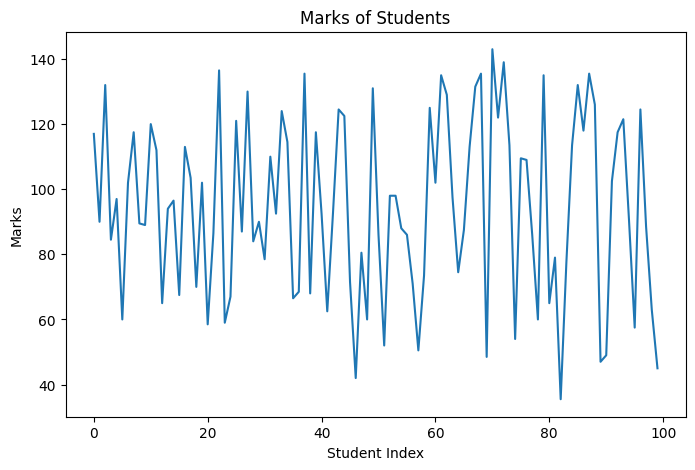

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(data['Marks'])

plt.title("Marks of Students")
plt.xlabel("Student Index")
plt.ylabel("Marks")

plt.show()

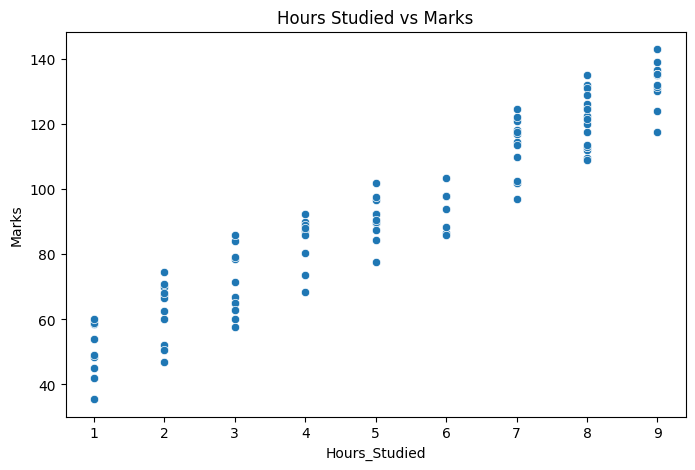

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Hours_Studied',
    y='Marks',
    data=data
)

plt.title("Hours Studied vs Marks")
plt.show()

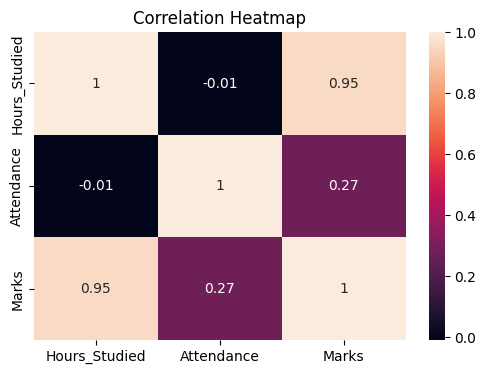

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    data.corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = data[['Hours_Studied', 'Attendance']]
y = data['Marks']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(2,)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 9535.7031 - mae: 93.7670 - val_loss: 9198.4043 - val_mae: 91.0652
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 9518.0869 - mae: 93.6742 - val_loss: 9181.8320 - val_mae: 90.9724
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 9500.1924 - mae: 93.5786 - val_loss: 9163.6621 - val_mae: 90.8701
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 9479.4717 - mae: 93.4688 - val_loss: 9143.7148 - val_mae: 90.7572
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 9457.8535 - mae: 93.3520 - val_loss: 9120.2744 - val_mae: 90.6285
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 9433.0742 - mae: 93.2234 - val_loss: 9094.1211 - val_mae: 90.4870
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 9406.2402 - mae: 93.0837 - val_loss: 9064.6436 - val_mae: 90.3307
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 9376.9219 - mae: 92.9342 - val_loss: 9032.0352 - val_mae: 90.1593
Epoch 9/50
8/8 ━

In [ ]:
loss, mae = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("MAE:", mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - loss: 2880.8599 - mae: 51.2950
Loss: 2880.85986328125
MAE: 51.2950439453125


In [ ]:
predictions = model.predict(X_test)

print(predictions[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
[[46.1403  ]
 [39.607285]
 [69.65921 ]
 [27.554295]
 [53.293526]]


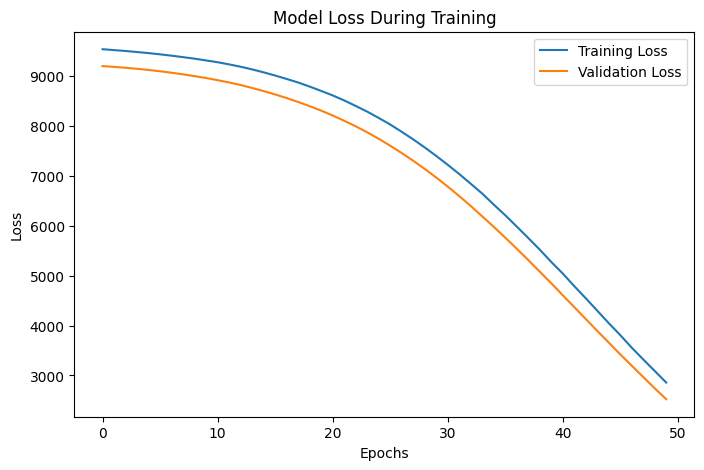

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss During Training")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()